# DeepSeek-Foundations · Workbook 04

### Information Theory — entropy, cross-entropy, KL divergence, and the loss of every LLM

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~60 min · **Prereqs:** Workbook 03 (lightly)

---

> **Abstract.** This workbook develops the information-theoretic objects that define what an LLM optimizes. We start from self-information and entropy — the measure of surprise and of expected surprise — then assemble joint and conditional entropy through the chain rule. Cross-entropy is introduced as the quantity every language model minimizes, and we show numerically that it is bounded below by entropy, with equality only for a perfect model; the KL divergence follows as the difference between the two, and its asymmetry and roles in distillation and RLHF are demonstrated. Perplexity closes the loop as the interpretable exponential of cross-entropy — the effective number of choices per token. Every equation is followed by executable NumPy code.

**How this fits the series.** Workbook 03 built probability distributions as first-class objects; this workbook attaches a *cost* to them. The loss that [Workbook 05 — Optimization](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/05_Optimization.ipynb)'s optimizers minimize, the softmax distribution that Workbook 07's transformer outputs, and the perplexity numbers reported in the [Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb) are all information-theoretic quantities. If you finish this workbook, you will never again wonder why the training objective of a language model is a sum of log-probabilities.

## 1. Self-information and entropy

**Self-information.** An event with probability $p$ carries information

$$I(p) = -\log_2 p \quad \text{bits}, \qquad I(p) = -\ln p \quad \text{nats}$$

The less probable the event, the more surprise (information) it carries: a fair coin flip that lands heads conveys $-\log_2(1/2) = 1$ bit; a 1-in-a-million event conveys about 20 bits. A *certain* event ($p = 1$) conveys 0 bits.

**Entropy.** The entropy of a distribution $p$ over a finite alphabet is the *expected* self-information:

$$H(p) = \mathbb{E}_{x \sim p}\big[-\log p(x)\big] = -\sum_x p(x) \log p(x)$$

Entropy is the minimal expected number of bits (with $\log_2$) or nats (with $\ln$) needed to describe a draw from $p$. It is maximized by the uniform distribution, $H = \log_2 K$ for $K$ symbols, and equals 0 for a deterministic distribution. In LLM terms: a model that assigns probability $p_\theta(x_{t+1} \mid x_{<t})$ to the next token is implicitly claiming "the next token costs $-\log_2 p_\theta$ bits to transmit".

H(fair coin)           = 1.0000 bits
H(biased coin)         = 0.4690 bits
H(uniform, 50 symbols) = 5.6439 bits  (log2(50) = 5.6439)
H(fair coin) in nats   = 0.6931


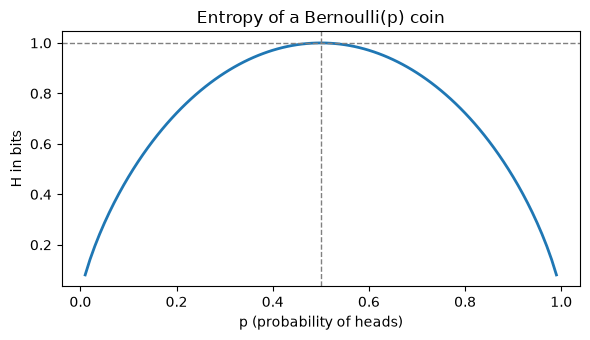

Max entropy = 1.0000 bits, achieved at p = 0.50


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(p, base=np.e):
    # Expected self-information of distribution p, in units given by base.
    p = np.asarray(p, dtype=float)
    p = p[p > 0]                # 0 * log 0 = 0 by convention
    return -np.sum(p * np.log(p)) / np.log(base)

# Fair coin: 2 equally likely outcomes -> exactly 1 bit
p_fair = np.array([0.5, 0.5])
# Biased coin: 90/10 -> less surprise on average
p_biased = np.array([0.9, 0.1])
# Uniform over 50 symbols -> log2(50) bits
K = 50
p_50 = np.full(K, 1.0 / K)

print("H(fair coin)           = %.4f bits" % entropy(p_fair, 2))
print("H(biased coin)         = %.4f bits" % entropy(p_biased, 2))
print("H(uniform, 50 symbols) = %.4f bits  (log2(50) = %.4f)" % (entropy(p_50, 2), np.log2(50)))
print("H(fair coin) in nats   = %.4f" % entropy(p_fair))

# Entropy of a Bernoulli(p) variable as a function of p (0.01 .. 0.99)
ps = np.linspace(0.01, 0.99, 99)
Hs = np.array([entropy(np.array([p, 1 - p]), 2) for p in ps])

plt.figure(figsize=(6, 3.5))
plt.plot(ps, Hs, lw=2)
plt.axvline(0.5, color="gray", ls="--", lw=1)
plt.axhline(1.0, color="gray", ls="--", lw=1)
plt.xlabel("p (probability of heads)")
plt.ylabel("H in bits")
plt.title("Entropy of a Bernoulli(p) coin")
plt.tight_layout()
plt.show()

print("Max entropy = %.4f bits, achieved at p = 0.50" % Hs.max())

## 2. Joint and conditional entropy

For a pair of variables $(X, Y)$ with joint distribution $p(x, y)$, the **joint entropy** is

$$H(X, Y) = -\sum_{x, y} p(x, y) \log p(x, y)$$

and the **conditional entropy** — the expected surprise of $Y$ once $X$ is known — is

$$H(Y \mid X) = \sum_x p(x)\, H(Y \mid X = x) = -\sum_{x, y} p(x, y) \log p(y \mid x)$$

The **chain rule** ties the three together:

$$H(X, Y) = H(X) + H(Y \mid X)$$

Knowing $X$ can only help: $H(Y \mid X) \le H(Y)$, with equality iff $X$ and $Y$ are independent. These identities are the algebraic backbone of everything that follows; the demo verifies them from a raw table of joint probabilities.

In [2]:
import numpy as np

# Joint distribution of two correlated binary variables X, Y in {0, 1}.
# X is fair; Y copies X with probability 0.85 and flips otherwise.
Pxy = np.array([[0.425, 0.075],   # P(X=0,Y=0)  P(X=0,Y=1)
                [0.075, 0.425]])  # P(X=1,Y=0)  P(X=1,Y=1)
assert np.isclose(Pxy.sum(), 1.0)

def entropy(p, base=np.e):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p)) / np.log(base)

Px = Pxy.sum(axis=1)                # marginal P(X)
Py = Pxy.sum(axis=0)                # marginal P(Y)
Py_given_x = Pxy / Px[:, None]      # rows: P(Y | X=x)
Px_given_y = Pxy / Py[None, :]      # cols: P(X | Y=y)

Hxy = entropy(Pxy.ravel())
Hx  = entropy(Px)
Hy  = entropy(Py)
Hy_given_x = sum(Px[x] * entropy(Py_given_x[x]) for x in range(2))
Hx_given_y = sum(Py[y] * entropy(Px_given_y[:, y]) for y in range(2))

print("H(X)      = %.4f nats" % Hx)
print("H(Y)      = %.4f nats" % Hy)
print("H(X, Y)   = %.4f nats" % Hxy)
print("H(Y | X)  = %.4f nats" % Hy_given_x)
print("H(X | Y)  = %.4f nats" % Hx_given_y)
print()
print("Chain rule  H(X,Y) == H(X) + H(Y|X):   %.4f == %.4f  ->  %s"
      % (Hxy, Hx + Hy_given_x, np.isclose(Hxy, Hx + Hy_given_x)))
print("Conditioning helps  H(Y|X) <= H(Y):     %.4f <= %.4f  ->  %s"
      % (Hy_given_x, Hy, Hy_given_x <= Hy))

H(X)      = 0.6931 nats
H(Y)      = 0.6931 nats
H(X, Y)   = 1.1159 nats
H(Y | X)  = 0.4227 nats
H(X | Y)  = 0.4227 nats

Chain rule  H(X,Y) == H(X) + H(Y|X):   1.1159 == 1.1159  ->  True
Conditioning helps  H(Y|X) <= H(Y):     0.4227 <= 0.6931  ->  True


## 3. Cross-entropy — the loss of every LLM

A language model assigns probability $q(x)$ to symbols, but the true data distribution is $p(x)$. The **cross-entropy** measures the expected surprise *under the true distribution* when we code with $q$:

$$H(p, q) = -\sum_x p(x) \log q(x)$$

This is exactly the objective minimized in LLM training: with $p$ the empirical distribution over next tokens and $q = p_\theta$, the training loss is $\mathcal{L}(\theta) = H(p, p_\theta)$ — equivalently $\mathbb{E}\big[-\log p_\theta(x_{t+1} \mid x_{<t})\big]$. Two facts drive everything:

1. **Gibbs' inequality:** $H(p, q) \ge H(p)$, with equality iff $q = p$. You can never beat the true distribution's own code.
2. Cross-entropy decomposes as $H(p, q) = H(p) + D_{\mathrm{KL}}(p \| q)$ — entropy plus a non-negative penalty — which is why minimizing cross-entropy is equivalent to minimizing the KL divergence.

In [3]:
import numpy as np

def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def cross_entropy(p, q):
    p = np.asarray(p, dtype=float)
    q = np.clip(np.asarray(q, dtype=float), 1e-12, None)   # guard log(0)
    return -np.sum(p * np.log(q))

# True distribution over 6 symbols, and three models: close, far, exact.
p = np.array([0.30, 0.25, 0.20, 0.15, 0.07, 0.03])
q_close = np.array([0.28, 0.26, 0.19, 0.16, 0.07, 0.04])
q_far   = np.array([0.50, 0.20, 0.10, 0.10, 0.05, 0.05])
q_exact = p.copy()

for name, q in [("q_close (good)", q_close), ("q_far (bad)", q_far), ("q_exact (perfect)", q_exact)]:
    print("%-18s H(p) = %.4f   H(p,q) = %.4f   excess = %.4f nats"
          % (name, entropy(p), cross_entropy(p, q), cross_entropy(p, q) - entropy(p)))

# Gibbs' inequality: H(p,q) >= H(p) for every q
oks = [cross_entropy(p, q) >= entropy(p) - 1e-12 for q in [q_close, q_far, q_exact]]
print("\nH(p,q) >= H(p) for all three models:", all(oks))
print("Equality holds iff q == p:", np.isclose(cross_entropy(p, p), entropy(p)))

q_close (good)     H(p) = 1.6056   H(p,q) = 1.6084   excess = 0.0028 nats
q_far (bad)        H(p) = 1.6056   H(p,q) = 1.7158   excess = 0.1102 nats
q_exact (perfect)  H(p) = 1.6056   H(p,q) = 1.6056   excess = 0.0000 nats

H(p,q) >= H(p) for all three models: True
Equality holds iff q == p: True


In [4]:
import numpy as np

# A toy 'language model': predict the next character of a short string.
text = "attention is all you need"
chars = sorted(set(text))
counts = np.array([text.count(c) for c in chars], dtype=float)
p = counts / counts.sum()                     # empirical next-char distribution

# Two model distributions over the same alphabet:
q_good = 0.9 * p + 0.1 / len(chars)            # mostly right, slight smoothing
rng = np.random.default_rng(0)
q_bad  = rng.dirichlet(np.ones(len(chars)))    # random guessing

def cross_entropy(p, q):
    q = np.clip(np.asarray(q, dtype=float), 1e-12, None)
    return -np.sum(p * np.log(q))

print("alphabet:", "".join(chars))
print("true next-char distribution p:", np.round(p, 3))
print()
print("H(p)         = %.4f nats  (irreducible entropy of the text)" % cross_entropy(p, p))
print("H(p, q_good) = %.4f nats  (good model)" % cross_entropy(p, q_good))
print("H(p, q_bad)  = %.4f nats  (random model)" % cross_entropy(p, q_bad))
print()
print("The bad model pays %.2f extra nats per token." % (cross_entropy(p, q_bad) - cross_entropy(p, q_good)))

alphabet:  adeilnostuy
true next-char distribution p: [0.16 0.08 0.04 0.12 0.08 0.08 0.12 0.08 0.04 0.12 0.04 0.04]

H(p)         = 2.3798 nats  (irreducible entropy of the text)
H(p, q_good) = 2.3810 nats  (good model)
H(p, q_bad)  = 3.8490 nats  (random model)

The bad model pays 1.47 extra nats per token.


## 4. KL divergence — the extra bits you pay

The **Kullback–Leibler divergence** between $p$ and $q$ is the gap between cross-entropy and entropy:

$$D_{\mathrm{KL}}(p \| q) = H(p, q) - H(p) = \sum_x p(x) \log \frac{p(x)}{q(x)}$$

It answers: *"how many extra nats (or bits) do I pay, on average, for coding data drawn from $p$ with the code of $q$?"* Hence $D_{\mathrm{KL}}(p \| q) \ge 0$ with equality iff $p = q$ — but it is **not symmetric**: $D_{\mathrm{KL}}(p \| q) \ne D_{\mathrm{KL}}(q \| p)$ in general, so it is not a metric.

Where KL shows up in LLM practice:

- **Distillation (Hinton et al., 2015):** a student model is trained to minimize $D_{\mathrm{KL}}(\text{teacher output} \| \text{student output})$, transferring the teacher's soft target distribution.
- **RLHF:** the KL penalty keeps the policy from drifting off the reference model: $\text{reward} - \beta\, D_{\mathrm{KL}}(\pi_\theta \| \pi_{\text{ref}})$.
- **Variational methods** (VAEs, diffusion) minimize KL terms throughout — the same object recurs across generative modeling.

In [5]:
import numpy as np

def kl(p, q):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, None)
    q = np.clip(np.asarray(q, dtype=float), 1e-12, None)
    return np.sum(p * np.log(p / q))

def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def cross_entropy(p, q):
    q = np.clip(np.asarray(q, dtype=float), 1e-12, None)
    return -np.sum(p * np.log(q))

p = np.array([0.30, 0.25, 0.20, 0.15, 0.07, 0.03])
q = np.array([0.28, 0.26, 0.19, 0.16, 0.07, 0.04])

print("D_KL(p || q) = %.4f nats" % kl(p, q))
print("D_KL(q || p) = %.4f nats" % kl(q, p))
print("Asymmetric (they differ):", not np.isclose(kl(p, q), kl(q, p)))
print()
# Identity: D_KL(p||q) = H(p,q) - H(p)
print("D_KL(p||q) == H(p,q) - H(p):  %.4f == %.4f  ->  %s"
      % (kl(p, q), cross_entropy(p, q) - entropy(p),
         np.isclose(kl(p, q), cross_entropy(p, q) - entropy(p))))
print("Extra bits paid coding p with q: %.4f bits" % (kl(p, q) / np.log(2)))

D_KL(p || q) = 0.0028 nats
D_KL(q || p) = 0.0030 nats
Asymmetric (they differ): True

D_KL(p||q) == H(p,q) - H(p):  0.0028 == 0.0028  ->  True
Extra bits paid coding p with q: 0.0041 bits


## 5. Perplexity — the effective number of choices

Perplexity is the exponential of cross-entropy:

$$\mathrm{PPL}(p, q) = \exp\big(H(p, q)\big) \quad \text{(nats)} = 2^{\,H_2(p, q)} \quad \text{(bits)}$$

Interpretation: a model with perplexity $K$ is as confused, on average, as a uniform distribution over $K$ symbols — $K$ is the **effective number of choices per token**. An untrained model that assigns uniform probability over a 50-character alphabet has PPL 50; a model that always predicts the right character with certainty has PPL 1. Since PPL is a monotone transform of the loss, minimizing cross-entropy is exactly minimizing perplexity.

Reference points (stated modestly, because PPL is only comparable across identical tokenizers and corpora): the from-scratch tiny GPT in the Master Report reaches a test perplexity of **9.78** on its tiny corpus; frontier LLMs report single-digit perplexities on their own training distributions; an untrained uniform model over $K$ symbols sits at PPL $= K$.

In [6]:
import numpy as np

# Reuse the toy next-character model from Section 3.
text = "attention is all you need"
chars = sorted(set(text))
counts = np.array([text.count(c) for c in chars], dtype=float)
p = counts / counts.sum()
q_good = 0.9 * p + 0.1 / len(chars)
rng = np.random.default_rng(0)
q_bad = rng.dirichlet(np.ones(len(chars)))

def cross_entropy_bits(p, q):
    q = np.clip(np.asarray(q, dtype=float), 1e-12, None)
    return -np.sum(p * np.log2(q))

def perplexity(p, q):
    return 2.0 ** cross_entropy_bits(p, q)

print("PPL(uniform over %d chars) = %.1f   (untrained baseline)" % (len(chars), len(chars)))
print("PPL(good model)  = %.2f" % perplexity(p, q_good))
print("PPL(bad model)   = %.2f" % perplexity(p, q_bad))
print()
# Cross-check: PPL == exp(cross-entropy in nats)
ce_nats = -np.sum(p * np.log(np.clip(q_good, 1e-12, None)))
print("Cross-check PPL == exp(CE in nats):", np.isclose(perplexity(p, q_good), np.exp(ce_nats)))
print()
print("Reference points: tiny GPT in the Master Report reaches PPL 9.78;")
print("frontier LLMs report single-digit perplexities on their training distributions.")

PPL(uniform over 12 chars) = 12.0   (untrained baseline)
PPL(good model)  = 10.82
PPL(bad model)   = 46.95

Cross-check PPL == exp(CE in nats): True

Reference points: tiny GPT in the Master Report reaches PPL 9.78;
frontier LLMs report single-digit perplexities on their training distributions.


## 6. Mutual information (brief)

The **mutual information** between $X$ and $Y$ is how much learning $X$ tells you about $Y$:

$$I(X; Y) = H(X) - H(X \mid Y) = H(Y) - H(Y \mid X) = D_{\mathrm{KL}}\big(p(x, y) \,\|\, p(x)\,p(y)\big)$$

It is symmetric, non-negative, and zero exactly when $X$ and $Y$ are independent. It is the KL divergence between the true joint and the product of the marginals — "how far the joint is from independence." In practice it is the workhorse of feature selection (keep features with high $I(\text{feature}; \text{target})$, drop redundant ones) and of analyzing what learned representations capture.

In [7]:
import numpy as np

# Same correlated pair as Section 2.
Pxy = np.array([[0.425, 0.075],
                [0.075, 0.425]])
Px = Pxy.sum(axis=1)
Py = Pxy.sum(axis=0)

def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def kl(p, q):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, None)
    q = np.clip(np.asarray(q, dtype=float), 1e-12, None)
    return np.sum(p * np.log(p / q))

Hx = entropy(Px)
Px_given_y = Pxy / Py[None, :]
Hx_given_y = sum(Py[y] * entropy(Px_given_y[:, y]) for y in range(2))

I_def = Hx - Hx_given_y                                # H(X) - H(X|Y)
I_kl  = kl(Pxy.ravel(), np.outer(Px, Py).ravel())     # KL(joint || product of marginals)

print("I(X; Y) = H(X) - H(X|Y)              = %.4f nats" % I_def)
print("I(X; Y) = KL(p(x,y) || p(x)p(y))     = %.4f nats" % I_kl)
print("Both definitions agree:", np.isclose(I_def, I_kl))
print("An independent pair would give I = 0 (then Pxy = outer(Px, Py)).")

I(X; Y) = H(X) - H(X|Y)              = 0.2704 nats
I(X; Y) = KL(p(x,y) || p(x)p(y))     = 0.2704 nats
Both definitions agree: True
An independent pair would give I = 0 (then Pxy = outer(Px, Py)).


## Exercises

1. **Entropy of a three-sided die.** A die has face probabilities $0.5, 0.25, 0.25$. Compute $H$ in bits by hand, then confirm with NumPy. *Hint: $-\big(0.5\log_2 0.5 + 0.25\log_2 0.25 + 0.25\log_2 0.25\big)$.*
2. **Cross-entropy is not symmetric.** Take $p = [0.8, 0.2]$ and $q = [0.6, 0.4]$. Compute $H(p, q)$ and $H(q, p)$ and explain why they differ. *Hint: the first argument is the distribution averaged over — it sets the weights and the support.*
3. **Chain rule in code.** Build any $2 \times 3$ joint distribution, and verify $H(X, Y) = H(Y) + H(X \mid Y)$ and $H(X \mid Y) \le H(X)$. *Hint: reuse the marginal/conditional pattern of Section 2.*
4. **KL asymmetry.** Find two distributions where $D_{\mathrm{KL}}(p \| q)$ and $D_{\mathrm{KL}}(q \| p)$ differ by more than a factor of 2. *Hint: $p$ uniform over 4 symbols vs $q$ peaked on one symbol — guard $\log(0)$ with `np.clip`.*
5. **Perplexity of a uniform model.** Show that a model assigning uniform probability over a $K$-symbol alphabet has perplexity exactly $K$. *Hint: $2^{-(1/K)\sum_x \log_2(1/K)} = 2^{\log_2 K}$.*

## Solutions

1. $H = -\big(0.5\log_2 0.5 + 0.25\log_2 0.25 + 0.25\log_2 0.25\big) = 0.5 + 0.5 + 0.5 = 1.5$ bits. NumPy check: `entropy(np.array([0.5, 0.25, 0.25]), 2)` returns `1.5`.
2. $H(p, q) = -0.8\ln 0.6 - 0.2\ln 0.4 \approx 0.673$ nats, while $H(q, p) = -0.6\ln 0.8 - 0.4\ln 0.2 \approx 0.777$ nats. Cross-entropy averages over the *first* argument, so swapping changes which events are weighted — only $H(p, q) \ge H(p)$ (with $q$ second) is guaranteed.
3. With, e.g., `Pxy = np.array([[0.1, 0.2, 0.05], [0.25, 0.15, 0.25]])`: `np.isclose(Hxy, Hy + Hx_given_y)` is `True` (the chain rule is an algebraic identity), and conditioning reduces entropy, $H(X \mid Y) \le H(X)$.
4. Take $p$ uniform over 4 symbols and $q = [1, 0, 0, 0]$. Then $D_{\mathrm{KL}}(p \| q) = \infty$ — the uniform mass on symbols 2–4 is impossible under $q$ — while $D_{\mathrm{KL}}(q \| p) = \ln 4 \approx 1.386$ nats. Clipping $q$ at `1e-12` turns the infinite term into a large finite number instead.
5. $H_2(p, q) = -\sum_x \frac{1}{K}\log_2\frac{1}{K} = \log_2 K$, so $\mathrm{PPL} = 2^{\log_2 K} = K$. A uniform model is exactly as confused as a fair $K$-way choice.

**Next →** [Workbook 05 — Optimization](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/05_Optimization.ipynb)

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)